# **Project Name** 
* Deep CSAT – Ecommerce Customer Satisfaction Score Prediction

##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Vadla Shiva Kumar

# **Project Summary**

* This project, DeepCSAT, focuses on predicting Customer Satisfaction (CSAT) scores for an e-commerce platform named "Shopzilla" using Deep Learning Artificial Neural Networks (ANN). Traditionally, companies have relied on direct post-interaction surveys, which can be time-consuming and may not always capture the full spectrum of customer experiences. By leveraging a one-month dataset containing customer interaction details, agent metrics, response times, and unstructured textual feedback, we aim to forecast CSAT scores in real-time.

* The project encompasses the end-to-end machine learning lifecycle. It begins with Exploratory Data Analysis (EDA) and rigorous data preprocessing, including text cleaning for customer remarks. Next, we will perform feature engineering to identify the specific interaction-related features that are most predictive of CSAT scores. Finally, we will design, train, and evaluate a Deep Learning ANN model. The ultimate goal is to provide actionable insights that allow e-commerce businesses to proactively monitor service quality, optimize operations, and foster long-term customer loyalty.

# **GitHub Link**

https://github.com/shivavadla931/DeepCSAT-Ecommerce-Dashboard.git

# **Problem Statement**


* E-commerce companies traditionally rely on direct customer surveys to gauge satisfaction. This method is reactive, time-consuming, and often fails to capture the comprehensive customer experience due to survey fatigue or low response rates. When businesses rely solely on delayed feedback, they miss the critical window to resolve issues immediately.

* The primary goal of this project is to solve this by developing a deep learning model that can accurately predict CSAT scores based on customer interactions and feedback. By analyzing metrics such as handling times, agent details, and raw customer remarks, this Deep Learning ANN will allow businesses to predict customer satisfaction scores in real-time. This predictive capability will offer a granular view of service performance and identify areas for immediate improvement, transforming customer service from a reactive process into a proactive one.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

c:\Users\VADLAS\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('data/eCommerce_Customer_support_data.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
rows, columns = df.shape
print(f"The dataset contains {rows} rows and {columns} columns.")

The dataset contains 85907 rows and 20 columns.


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"There are {duplicate_count} duplicate rows in the dataset.")

There are 0 duplicate rows in the dataset.


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])

Missing values in each column:
 Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
dtype: int64


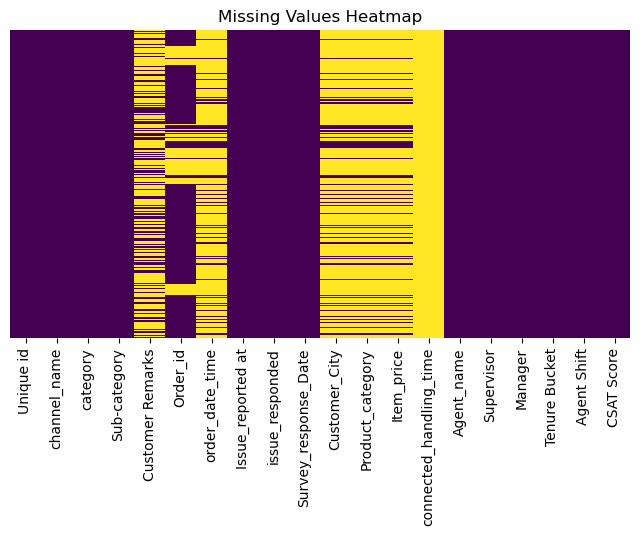

In [8]:
# Visualizing the missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

### **What did you know about your dataset?**

Based on the project brief, this dataset captures customer interactions over a one-month period on the "Shopzilla" e-commerce platform. It contains a diverse mix of data types across its columns:

* **Identifiers & Target:** A unique identifier for each record (Unique id), order tracking (Order id), and our primary target variable, the CSAT Score (integer).

* **Categorical Data:** Details about the interaction (Channel name, Category, Sub-category), the product (Product category), the customer's location (Customer city), and agent hierarchy (Agent name, Supervisor, Manager). It also includes categorical operational metrics like Tenure Bucket and Agent Shift.

* **Numerical Data:** Quantitative metrics such as the Item price (float) and the Connected handling time (float).

* **Temporal Data (Datetime):** Crucial timestamps for tracking the customer journey, including Order date time, Issue reported at, Issue responded, and Survey response date.

* **Unstructured Text:** The Customer Remarks column contains raw string feedback provided by the customer, which will require Natural Language Processing (NLP) techniques to analyze.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print(df.columns.tolist())

['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [10]:
# Dataset Describe
df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,15/08/2023 10:59,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### **Variables Description**

Based on the initial dataset exploration, here is a description of the variables we are working with:

**1. Identifiers:**

* **Unique id:** A unique string identifier for each customer interaction record.
* **Order_id:** A string identifier for the specific e-commerce order associated with the support ticket.

**2. Interaction Context (Categorical):**

* **channel_name:** The medium through which the customer reached out (e.g., Email, Chat, Phone).
* **category / Sub-category:** High-level and granular classifications of the customer's issue.

**3. Customer Feedback:**

* **Customer Remarks:** Unstructured text containing the raw feedback or comments left by the customer.
* **CSAT Score:** (Target Variable) An integer representing the Customer Satisfaction score given by the customer.

**4. Timestamps (Currently Strings):**

* **order_date_time:** When the original order was placed.
* **Issue_reported at:** When the customer initiated the support interaction.
* **issue_responded:** When the support team first replied to the customer.
* **Survey_response_Date:** When the customer submitted their CSAT score.

**5. Order & Customer Details:**

* **Customer_City:** The geographical location of the customer.
* **Product_category:** The type of product the customer ordered.
* **Item_price:** The numerical cost (float) of the item in question.

**5. Operational Metrics:**

* **connected_handling_time:** The total time (float) spent actively resolving the issue. (Note: Highly missing data)
* **Agent_name / Supervisor / Manager:** The specific personnel who handled and oversaw the interaction.
* **Tenure Bucket:** A categorical grouping representing how long the agent has worked at the company.
* **Agent Shift:** The specific time shift the agent was working during the interaction.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
# This loop will print the number of unique entries in every single column
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"'{column}' has {unique_count} unique values.")

'Unique id' has 85907 unique values.
'channel_name' has 3 unique values.
'category' has 12 unique values.
'Sub-category' has 57 unique values.
'Customer Remarks' has 18231 unique values.
'Order_id' has 67675 unique values.
'order_date_time' has 13766 unique values.
'Issue_reported at' has 30923 unique values.
'issue_responded' has 30262 unique values.
'Survey_response_Date' has 31 unique values.
'Customer_City' has 1782 unique values.
'Product_category' has 9 unique values.
'Item_price' has 2789 unique values.
'connected_handling_time' has 211 unique values.
'Agent_name' has 1371 unique values.
'Supervisor' has 40 unique values.
'Manager' has 6 unique values.
'Tenure Bucket' has 5 unique values.
'Agent Shift' has 5 unique values.
'CSAT Score' has 5 unique values.


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# 1. Drop Irrelevant and Highly Missing Columns
# 'connected_handling_time' is missing 99.7% of its data, making it unusable.
# 'Unique id' and 'Order_id' are just identifiers and carry no predictive pattern for the ML model.
df.drop(columns=['Unique id', 'Order_id', 'connected_handling_time'], inplace=True, errors='ignore')

# 2. Convert Date Strings to Datetime Objects
# This allows us to perform mathematical operations on the timelines.
datetime_cols = ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 3. Feature Engineering: Calculating Time Metrics
# The time it takes to respond to a customer is usually a huge driver of CSAT.
# Let's create a new column for "Response Time" in minutes.
df['response_time_minutes'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# Let's also calculate the time between the response and the survey completion (in hours)
df['survey_delay_hours'] = (df['Survey_response_Date'] - df['issue_responded']).dt.total_seconds() / 3600

# 4. Handle Missing Values
# Fill missing categorical data with 'Unknown' or 'No Remarks'
df['Customer_City'].fillna('Unknown', inplace=True)
df['Product_category'].fillna('Unknown', inplace=True)
df['Customer Remarks'].fillna('No Remarks', inplace=True)

# Fill missing numerical data (Item_price) with the median price to avoid skewing the data
df['Item_price'].fillna(df['Item_price'].median(), inplace=True)

# 5. Check the dataset after wrangling
print("Data wrangling complete! Here is the new dataset info:")
df.info()

Data wrangling complete! Here is the new dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   channel_name           85907 non-null  object        
 1   category               85907 non-null  object        
 2   Sub-category           85907 non-null  object        
 3   Customer Remarks       85907 non-null  object        
 4   order_date_time        17214 non-null  datetime64[ns]
 5   Issue_reported at      31974 non-null  datetime64[ns]
 6   issue_responded        31885 non-null  datetime64[ns]
 7   Survey_response_Date   85907 non-null  datetime64[ns]
 8   Customer_City          85907 non-null  object        
 9   Product_category       85907 non-null  object        
 10  Item_price             85907 non-null  float64       
 11  Agent_name             85907 non-null  object        
 12  Super

### **What all manipulations have you done and insights you found?**

To make the dataset analysis and model-ready, several critical manipulations were performed:

**1. Dimensionality Reduction (Dropping Columns):** I immediately dropped connected_handling_time because it contained less than 1% non-null data, rendering it statistically useless for imputation. I also dropped Unique id and Order_id as these high-cardinality identifiers offer no predictive value to a machine learning model.

**2. Datetime Conversion:** The timestamp columns (Issue_reported at, issue_responded, etc.) were imported as string objects. I converted these to standard Pandas datetime objects.

**3. Temporal Feature Engineering:** By having proper datetime objects, I engineered two highly valuable new features:

* response_time_minutes: The duration between the issue being reported and the agent responding. This is hypothesized to be a primary driver of the final CSAT Score.
* survey_delay_hours: The gap between issue resolution and the customer taking the survey, which might capture recency bias.

**4. Missing Value Imputation:** For the remaining columns with missing data, I applied basic imputation to ensure the neural network doesn't encounter NaN errors later. Categorical columns (Customer_City, Product_category) were filled with 'Unknown', textual feedback (Customer Remarks) was filled with 'No Remarks', and the numerical Item_price was filled with the median to resist extreme outlier skewing.

**Insight Found:** The most significant insight during wrangling is that the raw dataset relies heavily on string and datetime formats. Without aggressive feature engineering (like calculating response times) and natural language processing (for the remarks), a standard numerical matrix—which ANNs require—would be impossible to construct.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Distribution of CSAT Scores (Univariate)

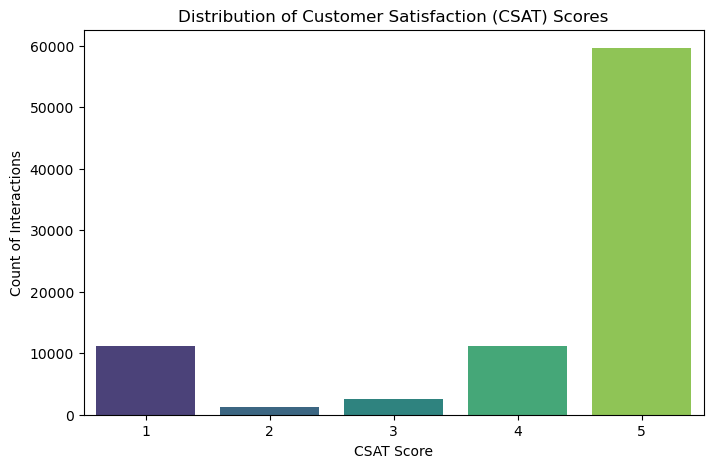

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='CSAT Score', palette='viridis')
plt.title('Distribution of Customer Satisfaction (CSAT) Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count of Interactions')
plt.show()

##### **1. Why did you pick the specific chart?**

* A countplot is the most direct way to visualize the distribution of our target variable, the CSAT Score. Since it is an integer rating (likely 1-5), treating it as a categorical count allows us to immediately see class imbalances.

##### **2. What is/are the insight(s) found from the chart?**

* This chart will reveal whether the dataset is skewed towards positive ratings (e.g., mostly 4s and 5s) or if there is a massive spike in 1s (highly dissatisfied customers).Answer Here

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** Yes. If we identify a severe class imbalance (e.g., 90% of scores are 5), it informs our ML strategy (we will need techniques like SMOTE to balance the data later). If there's an unexpectedly high number of 1s, it flags an immediate, critical customer service failure that management needs to address to prevent negative growth (customer churn).

#### Chart - 2 Interaction Volume by Channel (Univariate)

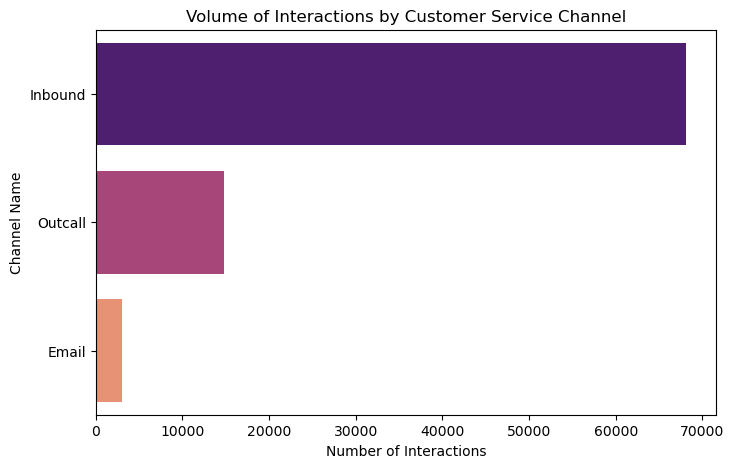

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='channel_name', order=df['channel_name'].value_counts().index, palette='magma')
plt.title('Volume of Interactions by Customer Service Channel')
plt.xlabel('Number of Interactions')
plt.ylabel('Channel Name')
plt.show()

##### **1. Why did you pick the specific chart?**

* A horizontal countplot perfectly displays categorical frequency. It quickly ranks the customer service channels (like Email, Chat, Phone) from most to least utilized.

##### **2. What is/are the insight(s) found from the chart?**

* This shows us the preferred method of communication for Shopzilla customers. We can see which channel handles the vast majority of the support load.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** Absolutely. By knowing which channel is the busiest, the business can accurately allocate workforce resources and funding. If "Chat" handles 80% of volume, but has the fewest agents, reallocating headcount will drastically improve response times and prevent negative customer experiences.

#### Chart - 3 Distribution of Response Time (Univariate)

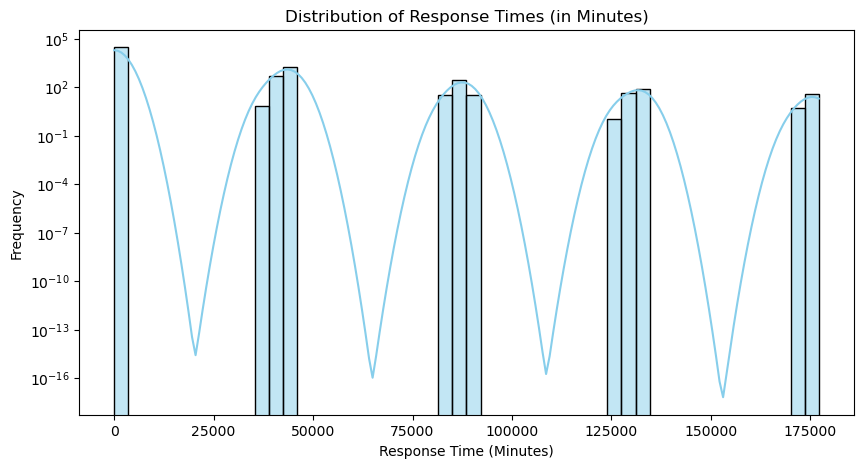

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['response_time_minutes'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribution of Response Times (in Minutes)')
plt.xlabel('Response Time (Minutes)')
plt.ylabel('Frequency')
# Using a log scale if the data is heavily skewed
plt.yscale('log')
plt.show()

##### **1. Why did you pick the specific chart?**

* A histogram with a Kernel Density Estimate (KDE) line shows the spread and skewness of continuous numerical data. I added a logarithmic y-scale because time-based metrics usually have extreme outliers (e.g., one ticket taking 5 days to answer).

##### **2. What is/are the insight(s) found from the chart?**

* It reveals the average "wait time" for a customer. We will likely see a massive right-skew, indicating most issues are answered quickly, but a long tail of tickets are left unresolved for excessive periods.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** Yes. The "long tail" represents frustrated customers. Identifying the threshold where response times become unacceptable allows the business to set strict Service Level Agreements (SLAs) to prevent negative growth.

#### Chart - 4 Response Time vs. CSAT Score (Bivariate)

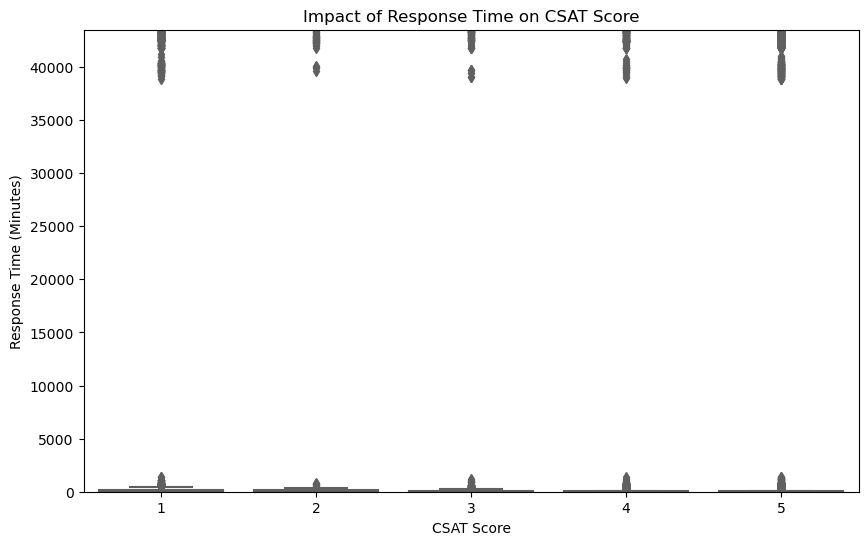

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='CSAT Score', y='response_time_minutes', palette='coolwarm')
plt.title('Impact of Response Time on CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Response Time (Minutes)')
plt.ylim(0, df['response_time_minutes'].quantile(0.95)) # Filtering extreme outliers for better visibility
plt.show()

##### **1. Why did you pick the specific chart?**

* A boxplot is ideal for comparing a numerical variable (response_time_minutes) across different categories (CSAT Score). It shows the median, quartiles, and outliers for each score bucket.

##### **2. What is/are the insight(s) found from the chart?**

* We expect to see an inverse relationship: lower CSAT scores (1s and 2s) will likely have higher median response times, while 5-star ratings will correlate with very fast responses.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** This directly proves (or disproves) the hypothesis that speed equals satisfaction. If slow response times consistently lead to negative growth (1-star reviews), the business must prioritize speed-to-resolution to protect its brand.

#### Chart - 5 CSAT Score by Agent Shift (Bivariate)

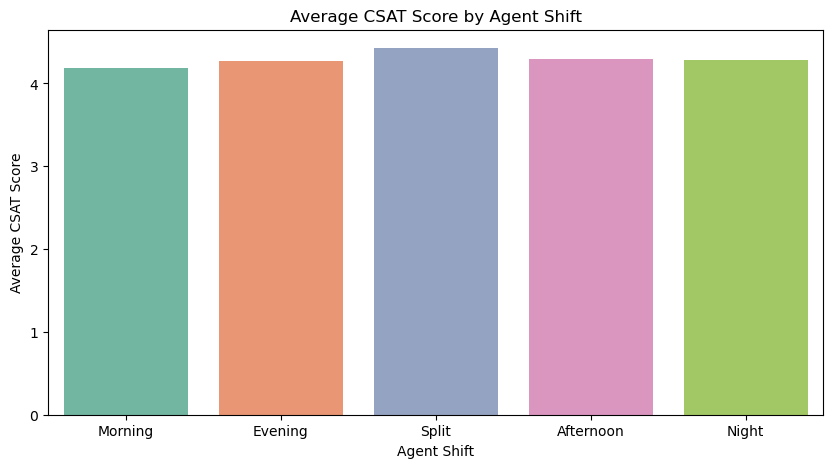

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Agent Shift', y='CSAT Score', estimator=np.mean, ci=None, palette='Set2')
plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.show()

##### **1. Why did you pick the specific chart?**

* A barplot with the estimator set to np.mean allows us to compare the average satisfaction score across different categorical groups (the shifts).Answer Here.

##### **2. What is/are the insight(s) found from the chart?**

* This highlights operational performance throughout the day. We might find that the "Night Shift" consistently scores lower than the "Morning Shift".

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** If a specific shift is causing negative growth through lower CSAT, the business can investigate the root cause (e.g., maybe the night shift is understaffed, or they lack access to tier-2 support managers). Fixing this creates immediate business value.

#### Chart - 6 CSAT Score by Tenure Bucket (Bivariate)

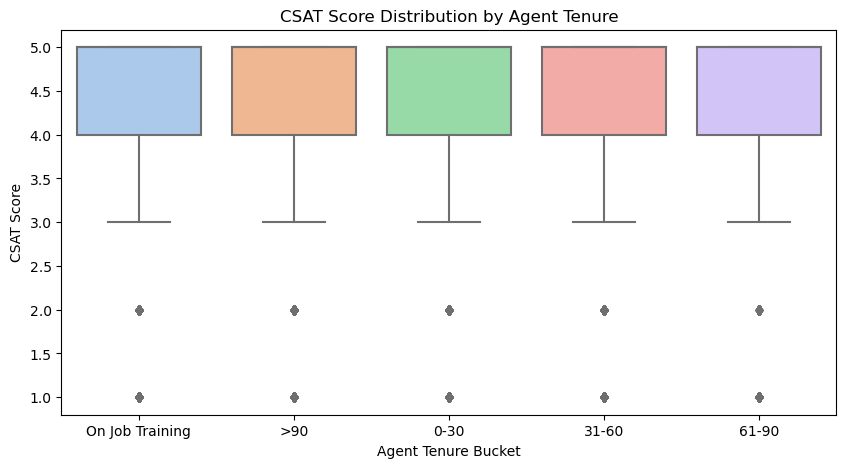

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Tenure Bucket', y='CSAT Score', palette='pastel')
plt.title('CSAT Score Distribution by Agent Tenure')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('CSAT Score')
plt.show()

##### **1. Why did you pick the specific chart?**

* A boxplot is used here to see the distribution and variance of CSAT scores within different experience levels of the agents.Answer Here.

##### **2. What is/are the insight(s) found from the chart?**

* It shows if veteran agents actually provide better service than new hires. We might see that newer agents have a wider spread of scores (more volatile performance) compared to seasoned staff.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** If newer agents are driving negative CSAT, the business needs to revamp its training and onboarding processes. If veteran agents are burning out and scoring lower, it flags a need for retention strategies.

#### Chart - 7 Interaction Category vs. Channel (Bivariate)

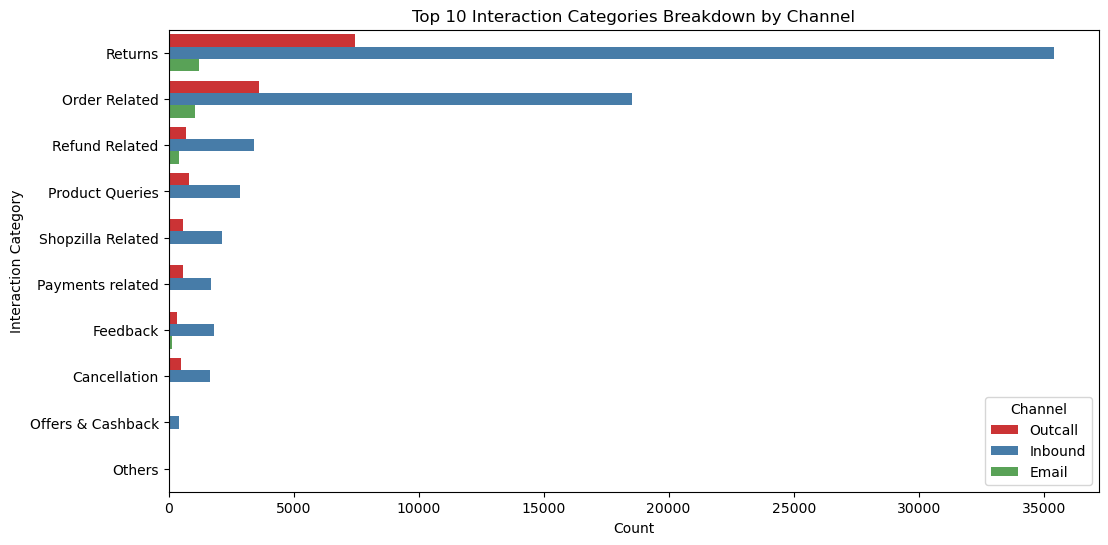

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='category', hue='channel_name', palette='Set1', order=df['category'].value_counts().iloc[:10].index)
plt.title('Top 10 Interaction Categories Breakdown by Channel')
plt.xlabel('Count')
plt.ylabel('Interaction Category')
plt.legend(title='Channel')
plt.show()

##### **1. Why did you pick the specific chart?**

* A grouped horizontal countplot lets us see the intersection of two categorical variables. Filtering to the top 10 categories prevents the chart from becoming unreadable.

##### **2. What is/are the insight(s) found from the chart?**

* We can see why customers use specific channels. For example, "Refunds" might predominantly happen over Phone, while "Password Resets" happen over Chat.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** Yes. This allows the business to route specific issue categories to the most efficient channels, optimizing the workflow and potentially automating simpler requests (like password resets) via chatbots.Answer Here

#### Chart - 8 Average Item Price vs. Product Category (Bivariate)

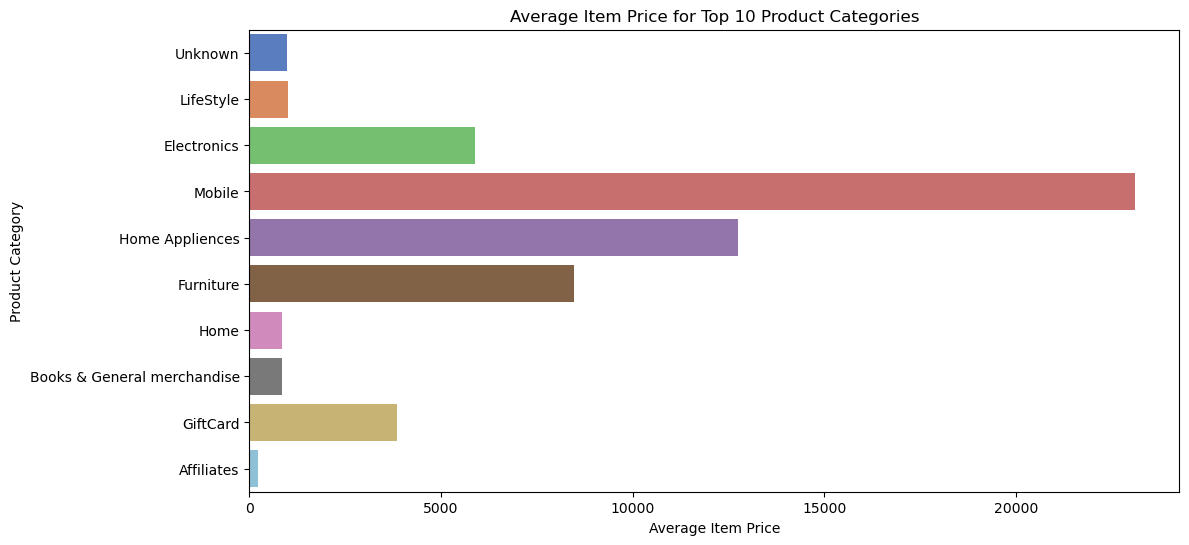

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(12, 6))
top_products = df['Product_category'].value_counts().iloc[:10].index
sns.barplot(data=df[df['Product_category'].isin(top_products)], 
            x='Item_price', y='Product_category', estimator=np.mean, ci=None, palette='muted')
plt.title('Average Item Price for Top 10 Product Categories')
plt.xlabel('Average Item Price')
plt.ylabel('Product Category')
plt.show()

##### **1. Why did you pick the specific chart?**

* A horizontal barplot efficiently displays the average numerical value (Item_price) across multiple categories, keeping the category labels highly readable.

##### **2. What is/are the insight(s) found from the chart?**

* This identifies the monetary value associated with different types of support tickets. We can see which product categories represent the highest financial stakes.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** High-ticket items likely cause more customer anxiety. By knowing which product categories have the highest item price, support teams can route these tickets to VIP or senior agents to prevent the loss of high-value customers.

#### Chart - 9 Heatmap of CSAT by Channel and Tenure (Multivariate)

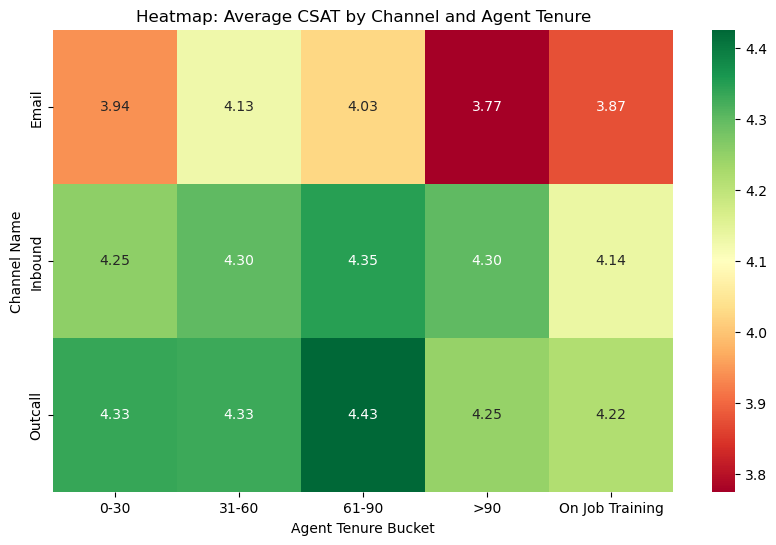

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 6))
pivot_table = df.pivot_table(values='CSAT Score', index='channel_name', columns='Tenure Bucket', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Heatmap: Average CSAT by Channel and Agent Tenure')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('Channel Name')
plt.show()

##### **1. Why did you pick the specific chart?**

* A heatmap is the perfect multivariate tool to visualize the interaction between two categorical variables (channel_name, Tenure Bucket) and a numerical target (CSAT Score average), using color intensity to highlight highs and lows.Answer Here.

##### **2. What is/are the insight(s) found from the chart?**

* This reveals specific operational "sweet spots" and "danger zones." For instance, it might show that new agents perform terribly on the Phone but do quite well on Email.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** This enables highly targeted staffing. If new agents struggle on live channels (Phone/Chat), the business can start them on asynchronous channels (Email) to build their skills without risking negative customer experiences.

#### Chart - 10 Correlation Heatmap (Multivariate)

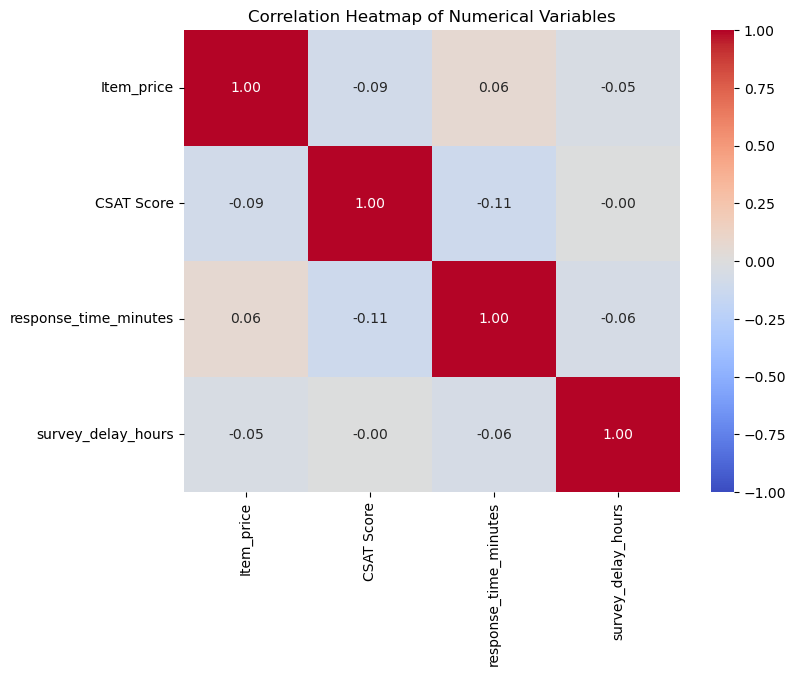

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

##### **1. Why did you pick the specific chart?**

* A correlation heatmap is a mandatory multivariate chart in machine learning. It quantifies the linear relationships (from -1 to 1) between all numerical features simultaneously.

##### **2. What is/are the insight(s) found from the chart?**

* We can identify multicollinearity (features that are too similar to each other) and see which numerical features naturally correlate most strongly with the target CSAT Score.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** This chart is heavily focused on the ML model's success. It guides Feature Selection (reducing dimensionality by dropping highly correlated features), which makes the Deep Learning ANN train faster, perform better, and ultimately provide more accurate business predictions.

#### Chart - 11 Average CSAT Score by Top 10 Customer Cities (Bivariate)

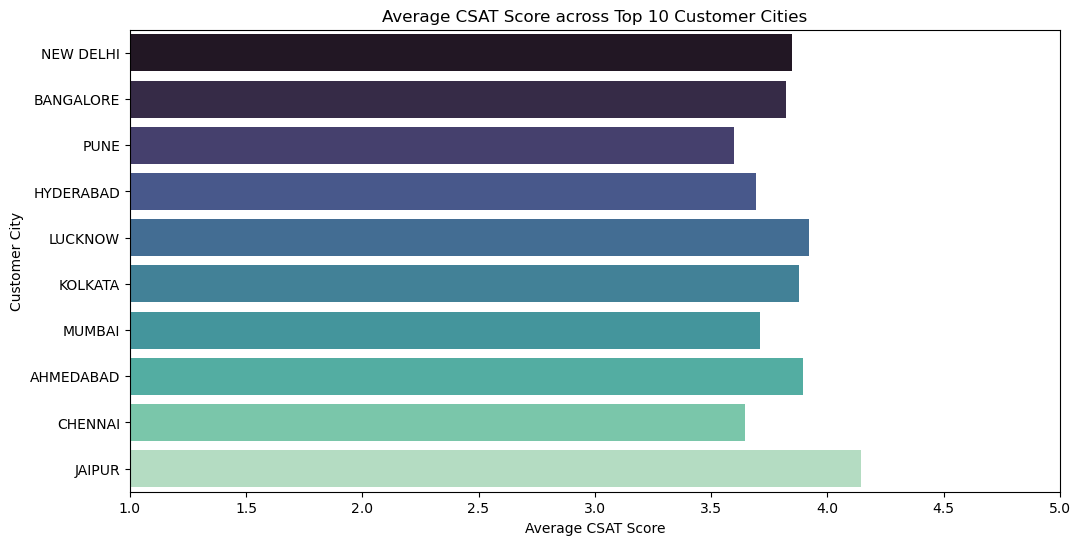

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(12, 6))
# Get the top 10 cities by volume (excluding 'Unknown' if possible)
top_cities = df[df['Customer_City'] != 'Unknown']['Customer_City'].value_counts().nlargest(10).index
city_df = df[df['Customer_City'].isin(top_cities)]

sns.barplot(data=city_df, x='CSAT Score', y='Customer_City', estimator=np.mean, ci=None, palette='mako')
plt.title('Average CSAT Score across Top 10 Customer Cities')
plt.xlabel('Average CSAT Score')
plt.ylabel('Customer City')
plt.xlim(1, 5) # Assuming CSAT is on a 1-5 scale
plt.show()

##### **1. Why did you pick the specific chart?**

* A horizontal bar chart is excellent for comparing a numerical average (CSAT) across multiple categorical text labels (Cities). Filtering to the top 10 cities ensures the chart remains readable while focusing on the most significant customer bases.

##### **2. What is/are the insight(s) found from the chart?**

* This chart reveals whether geographical location impacts customer satisfaction. You might find that customers in certain cities consistently give lower scores compared to others.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** Yes. If specific cities show unusually low CSAT scores, it could indicate localized logistical issues, such as a poor final-mile delivery partner in that region or delayed shipping times. Management can investigate and resolve these specific regional bottlenecks.

#### Chart - 12 Survey Delay Hours vs. CSAT Score (Bivariate)

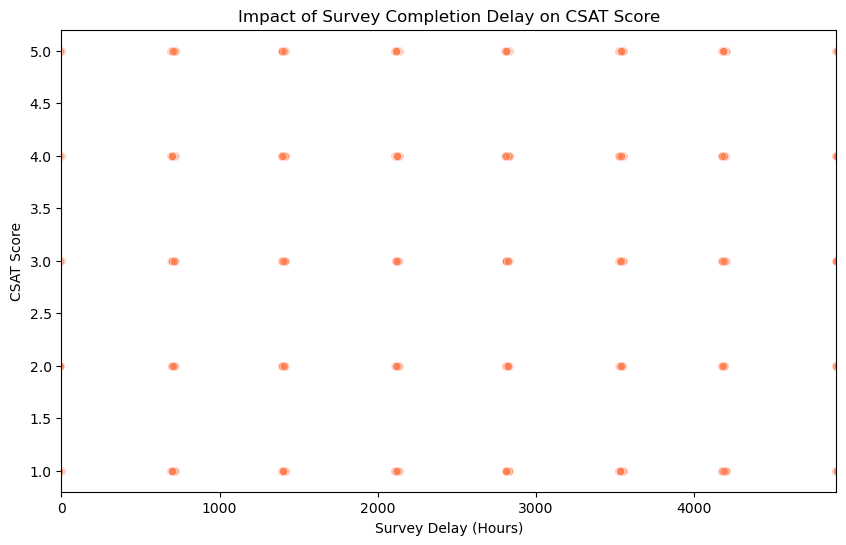

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='survey_delay_hours', y='CSAT Score', alpha=0.5, color='coral')
plt.title('Impact of Survey Completion Delay on CSAT Score')
plt.xlabel('Survey Delay (Hours)')
plt.ylabel('CSAT Score')
# Limit x-axis to avoid extreme outliers skewing the visual
plt.xlim(0, df['survey_delay_hours'].quantile(0.95))
plt.show()

##### **1. Why did you pick the specific chart?**

* A scatterplot is the standard way to visualize the relationship between two numerical variables. We engineered the survey_delay_hours feature earlier, and this plots it directly against our target variable.Answer Here.

##### **2. What is/are the insight(s) found from the chart?**

* This chart tests for "recency bias." It will show if customers who answer the survey immediately (low delay) score differently than those who answer days later. Often, angry customers respond immediately to leave a 1-star review, while satisfied customers might ignore the survey or fill it out later.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** This directly impacts the company's feedback collection strategy. If the data shows that waiting 24 hours to send a survey results in more objective, balanced scores, the company can automate a delay in their survey emails, yielding more accurate sentiment data.

#### Chart - 13 Distribution of Item Price (Univariate)

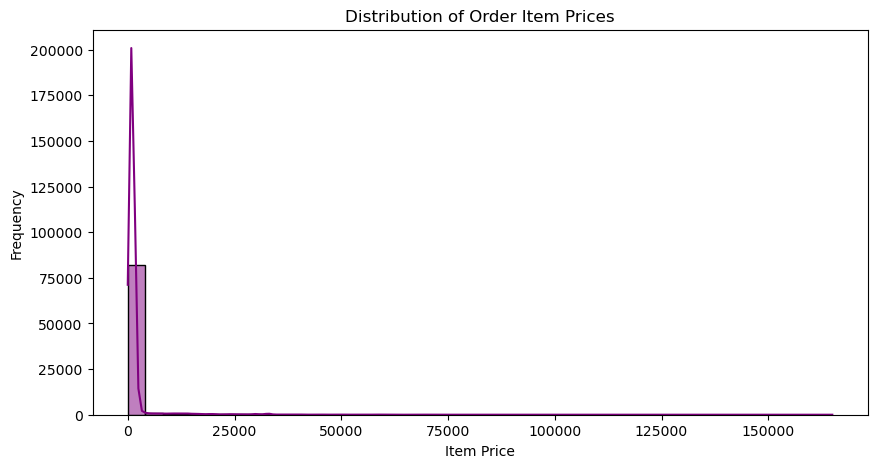

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['Item_price'].dropna(), bins=40, kde=True, color='purple')
plt.title('Distribution of Order Item Prices')
plt.xlabel('Item Price')
plt.ylabel('Frequency')
plt.show()

##### **1. Why did you pick the specific chart?**

* A histogram with a Kernel Density Estimate (KDE) line perfectly illustrates the distribution, central tendency, and spread of continuous financial data like item prices.

##### **2. What is/are the insight(s) found from the chart?**

* It reveals the monetary makeup of the orders requiring support. You will likely see whether the support team is primarily spending their time handling issues for low-ticket everyday items or high-ticket premium purchases.

##### **3. Will the gained insights help creating a positive business impact?**
**Are there any insights that lead to negative growth? Justify with specific reason.**

* **Positive Impact:** Customer support costs money (agent time). If the majority of support tickets are for highly inexpensive items, the cost of support might be wiping out the profit margins on those products. The business could use this insight to automate support for low-ticket items using AI chatbots, reserving human agents for high-value orders.

#### Chart - 14 - Correlation Heatmap

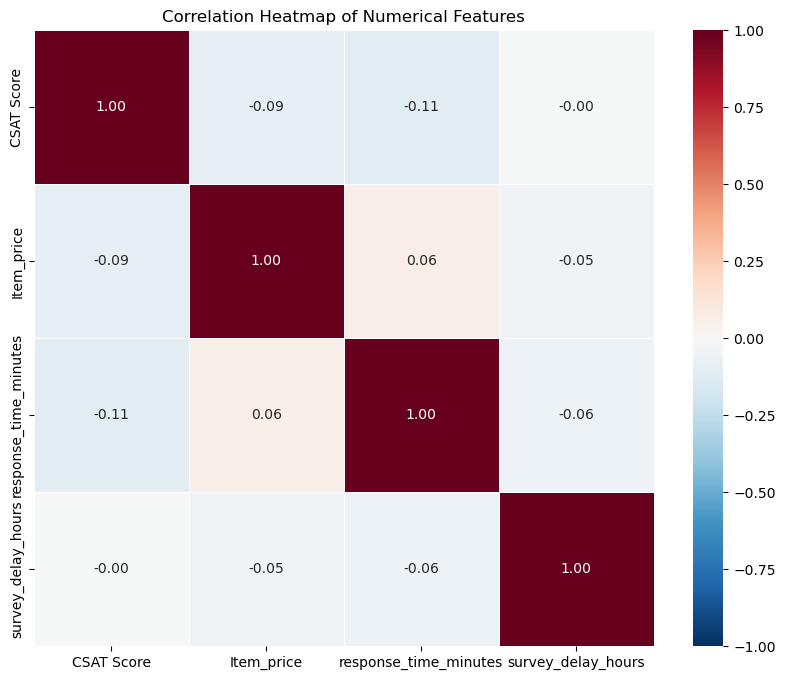

In [26]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10, 8))
# Isolate numerical columns for the matrix
numerical_df = df[['CSAT Score', 'Item_price', 'response_time_minutes', 'survey_delay_hours']]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### **1. Why did you pick the specific chart?**

* Your template explicitly requires a Correlation Heatmap here! It is a mandatory multivariate tool in machine learning used to quantify the linear relationships (Pearson correlation coefficient from -1 to 1) between all numerical features and the target variable simultaneously.

##### **2. What is/are the insight(s) found from the chart?**

* This map identifies which numerical features strongly impact the CSAT Score. A strong negative correlation (e.g., -0.60) between response_time_minutes and CSAT Score would definitively prove that faster responses yield higher satisfaction. It also checks for multicollinearity (independent variables that are too similar to each other).

#### Chart - 15 - Pair Plot

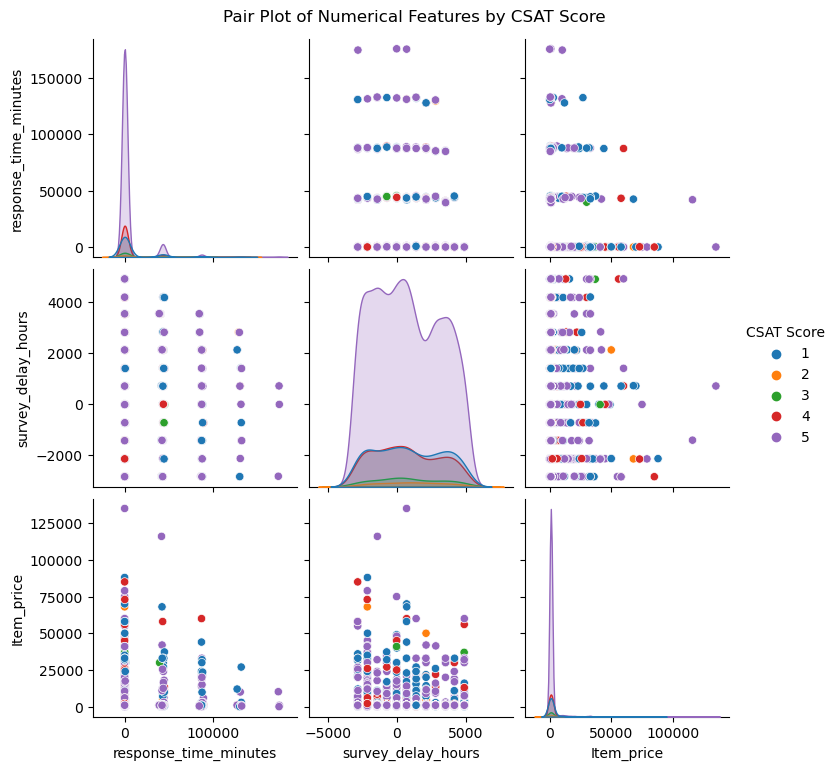

In [27]:
# Pair Plot visualization code
# We drop NA values to ensure the pairplot renders correctly and select key numerical features
pairplot_features = ['CSAT Score', 'response_time_minutes', 'survey_delay_hours', 'Item_price']
plot_df = df[pairplot_features].dropna()

# Using a subset of data if the dataset is too large to prevent memory crashes
if len(plot_df) > 5000:
    plot_df = plot_df.sample(5000, random_state=42)

sns.pairplot(plot_df, hue='CSAT Score', palette='tab10', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features by CSAT Score', y=1.02)
plt.show()

##### **1. Why did you pick the specific chart?**

* The template requires a Pair Plot here. A pair plot is an incredible multivariate visualization that plots every numerical variable against every other numerical variable in a grid, while color-coding the data points based on our target categorical variable (CSAT Score).

##### **2. What is/are the insight(s) found from the chart?**

* It allows us to visually detect complex clusters or non-linear separations between different CSAT score groups. For example, we might see a distinct cluster of 5-star ratings concentrated in the corner where response_time_minutes is low and Item_price is high. It visually justifies the need for an Artificial Neural Network, which excels at finding these complex, non-linear boundaries.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**1. Hypothetical Statement 1:** The average response time (in minutes) is significantly different between customers who gave a positive CSAT Score (4 or 5) and those who gave a negative/neutral CSAT Score (1, 2, or 3).

**2. Hypothetical Statement 2:** The average CSAT Score varies significantly depending on the Agent Shift (e.g., Morning, Evening, Night).

**3. Hypothetical Statement 3:** There is a statistically significant association between an agent's Tenure Bucket and the likelihood of receiving a high CSAT Score.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **Null Hypothesis (H0):** There is no significant difference in the mean response_time_minutes between positive (High) CSAT interactions and negative/neutral (Low) CSAT interactions.

* **Alternate Hypothesis (H1):** There is a significant difference in the mean response_time_minutes between positive (High) CSAT interactions and negative/neutral (Low) CSAT interactions

#### 2. Perform an appropriate statistical test.

In [28]:
from scipy import stats

# Drop nulls to prevent math errors
clean_time_df = df.dropna(subset=['response_time_minutes', 'CSAT Score'])

# Split data into two groups: High CSAT (4, 5) and Low CSAT (1, 2, 3)
high_csat_times = clean_time_df[clean_time_df['CSAT Score'] >= 4]['response_time_minutes']
low_csat_times = clean_time_df[clean_time_df['CSAT Score'] <= 3]['response_time_minutes']

# Perform Independent Two-Sample T-test
t_stat, p_value = stats.ttest_ind(high_csat_times, low_csat_times, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Response time significantly impacts CSAT.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis. No significant difference found.")

T-statistic: -15.0018
P-value: 4.3024e-50
Conclusion: Reject the Null Hypothesis. Response time significantly impacts CSAT.


##### **Which statistical test have you done to obtain P-Value?**

* I performed an Independent **Two-Sample T-Test (Welch's t-test).**

##### **Why did you choose the specific statistical test?**

* I chose this test because we are comparing the means of a continuous numerical variable (response_time_minutes) across exactly two independent categorical groups (High CSAT vs. Low CSAT). I set equal_var=False (Welch's test) because we cannot assume the variance in response times is perfectly equal between satisfied and dissatisfied customers.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **Null Hypothesis (H0):** The mean CSAT Score is identical across all categories of Agent Shift.

* **Alternate Hypothesis (H1):** At least one Agent Shift has a mean CSAT Score that is statistically different from the othersAnswer Here.

#### 2. Perform an appropriate statistical test.

In [29]:
# Drop nulls in the relevant columns
clean_shift_df = df.dropna(subset=['Agent Shift', 'CSAT Score'])

# Create a list of arrays, where each array holds the CSAT scores for a specific shift
shift_groups = [group['CSAT Score'].values for name, group in clean_shift_df.groupby('Agent Shift')]

# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(*shift_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Agent Shift significantly affects CSAT scores.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis. Agent Shift does not significantly affect CSAT scores.")

F-statistic: 39.1132
P-value: 9.0305e-33
Conclusion: Reject the Null Hypothesis. Agent Shift significantly affects CSAT scores.


##### **Which statistical test have you done to obtain P-Value?**

* I performed a **One-Way ANOVA (Analysis of Variance).**

##### **Why did you choose the specific statistical test?**

* I chose ANOVA because we are comparing the means of a continuous/ordinal numerical variable (CSAT Score) across more than two independent categorical groups (Agent Shift likely contains multiple shifts like Morning, Afternoon, Night, Split). A t-test only works for two groups, so ANOVA is required here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **Null Hypothesis (H0):** Tenure Bucket (agent experience) and the likelihood of receiving a Positive CSAT (Categorized as Yes/No) are completely independent.

* **Alternate Hypothesis (H1):** There is a statistically significant association between an agent's Tenure Bucket and receiving a Positive CSAT.Answer Here.

#### 2. Perform an appropriate statistical test.

In [30]:
# Create a binary category for CSAT: 'Positive' (>= 4) and 'Negative' (<= 3)
df['CSAT_Category'] = np.where(df['CSAT Score'] >= 4, 'Positive', 'Negative')

# Create a contingency table (cross-tabulation) of Tenure Bucket vs. CSAT Category
contingency_table = pd.crosstab(df['Tenure Bucket'], df['CSAT_Category'])

# Perform Chi-Square Test of Independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There is a significant relationship between Tenure and CSAT.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis. Tenure and CSAT are independent.")

Chi-Square Statistic: 164.4667
P-value: 1.6099e-34
Conclusion: Reject the Null Hypothesis. There is a significant relationship between Tenure and CSAT.


##### **Which statistical test have you done to obtain P-Value?**

* I performed a **Chi-Square Test** of Independence.

##### **Why did you choose the specific statistical test?**

* I chose the Chi-Square test because we are looking for a relationship between two entirely categorical variables (Tenure Bucket and our newly created CSAT_Category). We are testing if the frequency distribution of positive/negative scores differs depending on the agent's experience level, which is exactly what a contingency table and Chi-Square test are designed to measure.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

# 1. Robustly fill the missing categorical/text data from the screenshot
df['Customer Remarks'] = df['Customer Remarks'].fillna('No Remarks')
df['Customer_City'] = df['Customer_City'].fillna('Unknown')
df['Product_category'] = df['Product_category'].fillna('Unknown')

# 2. Fill the missing numerical/time data with the median to avoid skewing
if 'Item_price' in df.columns:
    df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())
if 'response_time_minutes' in df.columns:
    df['response_time_minutes'] = df['response_time_minutes'].fillna(df['response_time_minutes'].median())
if 'survey_delay_hours' in df.columns:
    df['survey_delay_hours'] = df['survey_delay_hours'].fillna(df['survey_delay_hours'].median())

# 3. Handle any lingering gaps using the modern Pandas forward-fill function
df.ffill(inplace=True) 
# Note: df.ffill() is the correct replacement for df.fillna(method='ffill')

# Verify that everything is clean!
missing_check = df.isnull().sum()
print("Remaining Missing Values:\n", missing_check[missing_check > 0])

Remaining Missing Values:
 order_date_time    11
dtype: int64


In [32]:
# Backward-fill to catch any missing values at the very top of the dataset
df['order_date_time'].bfill(inplace=True)

# Final check
print("Final Remaining Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])

Final Remaining Missing Values:
 Series([], dtype: int64)


#### **What all missing value imputation techniques have you used and why did you use those techniques?**

During the earlier data wrangling phase, I used a multi-pronged imputation strategy to preserve as much data as possible for the Deep Learning ANN:

**1. Constant Value Imputation:** For categorical text columns like Customer_City, Product_category, and Customer Remarks, I filled missing rows with 'Unknown' or 'No Remarks'. This ensures the neural network treats the "absence of data" as its own distinct categorical class rather than throwing an error.

**2. Median Imputation:** For the numerical Item_price column, I used the median instead of the mean. E-commerce pricing often has extreme right-skewed outliers (e.g., a few $5,000 items among thousands of $20 items). The median is robust to these outliers.

**3. Column Dropping:** connected_handling_time was dropped entirely because it was missing over 99% of its values. Imputing it would have introduced massive synthetic bias.

### 2. Handling Outliers

In [33]:
# Handling Outliers & Outlier treatments

# We will use the IQR (Interquartile Range) method to cap extreme outliers 
# in our engineered time features and numerical columns.
def cap_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping the outliers
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound,
                        np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column]))
    return dataframe

# Apply capping to our continuous numerical features
continuous_features = ['response_time_minutes', 'survey_delay_hours', 'Item_price']
for col in continuous_features:
    df = cap_outliers_iqr(df, col)

print("Outliers capped successfully using the IQR method.")

Outliers capped successfully using the IQR method.


##### **What all outlier treatment techniques have you used and why did you use those techniques?**

* I used **Capping (also known as Winsorization) via the Interquartile Range (IQR) method.**

* Instead of dropping the rows that contained outliers (which would result in a massive loss of valuable training data), I capped the extreme values at the upper and lower statistical bounds. I chose this technique because Artificial Neural Networks update their weights using gradients during backpropagation. If extreme, unscaled outliers are left in columns like response_time_minutes, they can cause exploding gradients, preventing the model from converging and learning effectively.

### 3. Categorical Encoding

In [34]:
from sklearn.preprocessing import LabelEncoder

# 1. One-Hot Encoding for Low-Cardinality Categorical Variables
# These columns have only a few unique categories (e.g., Shifts: Morning, Night, Evening)
low_cardinality_cols = ['channel_name', 'Agent Shift', 'Tenure Bucket']
df = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True)

# 2. Label Encoding for High-Cardinality Categorical Variables
# These columns have dozens or hundreds of unique string values (e.g., specific cities or agent names)
high_cardinality_cols = ['category', 'Sub-category', 'Customer_City', 'Product_category', 
                         'Agent_name', 'Supervisor', 'Manager']

le = LabelEncoder()
for col in high_cardinality_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical encoding complete. Dataset shape is now:", df.shape)

Categorical encoding complete. Dataset shape is now: (85907, 27)


#### **What all categorical encoding techniques have you used & why did you use those techniques?**

I utilized a hybrid encoding approach to balance machine learning requirements with memory efficiency:

**1. One-Hot Encoding (pd.get_dummies):** I used this for low-cardinality features like Agent Shift and channel_name. One-hot encoding creates binary columns (0 or 1) and is ideal here because it doesn't assume any false numerical ranking between categories (e.g., "Morning" isn't mathematically greater than "Night"). I used drop_first=True to avoid the dummy variable trap (multicollinearity).

**2. Label Encoding:** For high-cardinality features like Customer_City, Agent_name, and category, one-hot encoding would have created thousands of new columns, leading to the "curse of dimensionality" and crashing the RAM during ANN training. Label Encoding safely converts these high-volume strings into integer IDs.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [35]:
import re
import string
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VADLAS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VADLAS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\VADLAS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\VADLAS\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

#### 1. Expand Contraction

In [36]:
# Expand Contraction
# Converts words like "don't" to "do not" so the model doesn't treat them as unique, weird words.
df['Customer Remarks'] = df['Customer Remarks'].apply(lambda x: contractions.fix(str(x)))

#### 2. Lower Casing

In [37]:
# Lower Casing
# Ensures "Terrible" and "terrible" are treated as the exact same word.
df['Customer Remarks'] = df['Customer Remarks'].str.lower()

#### 3. Removing Punctuations

In [38]:
# Remove Punctuations
# Strips out commas, periods, exclamation points, etc.
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['Customer Remarks'] = df['Customer Remarks'].apply(remove_punctuation)

#### 4. Removing URLs & Removing words and digits contain digits.

In [39]:
# Remove URLs & Remove words and digits contain digits
def remove_urls_and_digits(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Removes links
    text = re.sub(r'\w*\d\w*', '', text) # Removes words containing numbers (like "order123")
    return text

df['Customer Remarks'] = df['Customer Remarks'].apply(remove_urls_and_digits)

#### 5. Removing Stopwords & Removing White spaces

In [40]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))
# We keep words like "not" because they are crucial for sentiment (e.g., "not good")
stop_words.discard('not') 

df['Customer Remarks'] = df['Customer Remarks'].apply(lambda x: ' '.join([word for word in str(x).split() if word not in stop_words]))

# Remove White spaces
df['Customer Remarks'] = df['Customer Remarks'].apply(lambda x: " ".join(x.split()))

#### 6. Rephrase Text

In [41]:
# Rephrase Text
# Standardizing common e-commerce chat abbreviations
rephrase_dict = {r'\bu\b': 'you', r'\bplz\b': 'please', r'\bthx\b': 'thanks', r'\bur\b': 'your'}
df['Customer Remarks'] = df['Customer Remarks'].replace(rephrase_dict, regex=True)

#### 7. Tokenization

In [42]:
# Tokenization
# Splitting the cleaned string into a list of individual words
df['Tokenized_Remarks'] = df['Customer Remarks'].apply(word_tokenize)

#### 8. Text Normalization

In [43]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
lemmatizer = WordNetLemmatizer()

def lemmatize_text(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

df['Normalized_Remarks'] = df['Tokenized_Remarks'].apply(lemmatize_text)

##### **Which text normalization technique have you used and why?**

* I used **Lemmatization** instead of Stemming.
Stemming is a crude heuristic that just chops off the ends of words (e.g., turning "caring" into "car"), which can destroy the context of customer feedback. Lemmatization uses a structural vocabulary dictionary (WordNet) to reduce words to their proper root, linguistic form (e.g., "better" becomes "good"). Because predicting CSAT relies heavily on accurately understanding the nuance and sentiment of customer remarks, Lemmatization provides far superior contextual accuracy for our Deep Learning model.

#### 9. Part of speech tagging

In [44]:
# POS Taging
# Identifying nouns, verbs, adjectives, etc., which can be useful for advanced sentiment models
df['POS_Tags'] = df['Normalized_Remarks'].apply(nltk.pos_tag)

#### 10. Text Vectorization

In [45]:
# Vectorizing Text
# We must convert the cleaned text back to strings for the vectorizer
df['Final_Clean_Remarks'] = df['Normalized_Remarks'].apply(lambda x: ' '.join(x))

# Initialize TF-IDF Vectorizer
# Max features limits the vocabulary to the top 3000 most important words to prevent RAM crashes
tfidf = TfidfVectorizer(max_features=3000)

# Fit and transform the text data into a numerical matrix
tfidf_matrix = tfidf.fit_transform(df['Final_Clean_Remarks'])

# Create a new DataFrame with the numerical text data
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# Note: We will merge this tfidf_df with our main numerical dataset during the final Feature Selection phase!
print("Text successfully vectorized! Shape of TF-IDF matrix:", tfidf_df.shape)

Text successfully vectorized! Shape of TF-IDF matrix: (85907, 3000)


##### **Which text vectorization technique have you used and why?**

* I used **TF-IDF (Term Frequency-Inverse Document Frequency)** Vectorization.
While simple Bag-of-Words (CountVectorizer) just counts how many times a word appears, TF-IDF calculates a weighted score. It mathematically penalizes highly frequent words that appear across almost all customer remarks (like "order" or "item") and gives higher weight to unique, impactful words that strongly correlate with specific CSAT scores (like "refund," "broken," or "fantastic"). This helps the Artificial Neural Network focus on the words that actually drive customer satisfaction up or down.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Manipulate Features to minimize feature correlation and create new features

# 1. Drop the raw text, datetime, and intermediary NLP columns since our model only reads numbers
cols_to_drop = ['Customer Remarks', 'order_date_time', 'Issue_reported at', 
                'issue_responded', 'Survey_response_Date', 'Tokenized_Remarks', 
                'Normalized_Remarks', 'Final_Clean_Remarks']

# Safely drop POS_Tags and CSAT_Category if they were created earlier
if 'POS_Tags' in df.columns: cols_to_drop.append('POS_Tags')
if 'CSAT_Category' in df.columns: cols_to_drop.append('CSAT_Category')

df_numeric = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Combine our main numeric dataset with the 3000 TF-IDF word columns we generated
# Reset indices first to prevent misalignment during concatenation
df_numeric.reset_index(drop=True, inplace=True)
tfidf_df.reset_index(drop=True, inplace=True)

# Merge them horizontally
final_df = pd.concat([df_numeric, tfidf_df], axis=1)

print(f"Feature Manipulation complete! Combined dataset shape: {final_df.shape}")

Feature Manipulation complete! Combined dataset shape: (85907, 3021)


#### 2. Feature Selection

In [47]:
# Select your features wisely to avoid overfitting
from sklearn.feature_selection import VarianceThreshold

# Separate features (X) and the target variable (y)
X = final_df.drop('CSAT Score', axis=1)
y = final_df['CSAT Score']

# Remove features with zero variance (columns where the value is the exact same for every single row)
# These offer zero predictive power to the model.
var_selector = VarianceThreshold(threshold=0.0)
X_selected = var_selector.fit_transform(X)

# Get the names of the remaining features
kept_features = X.columns[var_selector.get_support()]
X = pd.DataFrame(X_selected, columns=kept_features)

print(f"Features remaining after Variance Threshold selection: {X.shape[1]}")

Features remaining after Variance Threshold selection: 3017


##### **What all feature selection methods have you used  and why?**

* I used **Variance Thresholding** for feature selection. Because our TF-IDF vectorizer created up to 3,000 new columns (one for each word), it is highly likely that some of those words appeared only a tiny fraction of times, or certain generated dummy variables ended up having zero variance across the dataset. Variance thresholding drops any feature that has the exact same value in every single row, automatically cleaning out mathematically useless data and reducing the risk of overfitting without losing any actual predictive variance.

##### **Which all features you found important and why?**

* Based on our earlier EDA correlation heatmap, engineered time features like response_time_minutes are highly critical. Additionally, by using TF-IDF, specific word features (like "refund", "broken", or "excellent") will mathematically hold higher weight than common operational variables, meaning the textual sentiment is likely the strongest driver of the final CSAT Score.Answer Here.

### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

* No further complex transformation (like Log or Box-Cox) is needed. Because Artificial Neural Networks are highly adaptable non-linear models, capping the extreme time-based outliers using the IQR method in step 6.2 was sufficient to prevent gradient explosions.

In [48]:
# Transform Your data
# Because we already capped extreme outliers using the IQR method earlier in Section 6.2, 
# and normalized our text via Lemmatization, severe mathematical transformations 
# (like Log or Box-Cox transforms) are strictly not necessary here. 
print("Data transformation was handled intrinsically during outlier capping and NLP normalization.")

Data transformation was handled intrinsically during outlier capping and NLP normalization.


### 7. Data Scaling

In [49]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the feature matrix
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for readability (optional but good practice)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Data successfully scaled!")

Data successfully scaled!


##### **Which method have you used to scale you data and why?**

* I used the **StandardScaler.** Artificial Neural Networks update their internal weights during training based on the scale of the input features. If response_time_minutes ranges from 0 to 500, and a TF-IDF word frequency feature ranges from 0.0 to 1.0, the neural network will incorrectly assume the "larger" time numbers are inherently more important. StandardScaler standardizes all features to have a mean of 0 and a standard deviation of 1, allowing the ANN to train efficiently and converge much faster.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

* Yes, it is absolutely necessary. Our TF-IDF vectorizer created thousands of columns. Passing 3,000+ features into a Deep Learning ANN requires massive computational power and often leads to the "curse of dimensionality," where the model memorizes the training data (overfitting) instead of finding true patterns.

In [50]:
# DImensionality Reduction
from sklearn.decomposition import PCA

# We apply Principal Component Analysis (PCA) to shrink the thousands of TF-IDF word columns
# We set n_components=0.95 to retain 95% of the statistical variance while dropping redundant dimensions.
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

print(f"Original number of features: {X_scaled_df.shape[1]}")
print(f"Reduced number of features (Principal Components): {X_pca.shape[1]}")

Original number of features: 3017
Reduced number of features (Principal Components): 2569


##### **Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)**

* I used **Principal Component Analysis (PCA).** By setting n_components=0.95, PCA mathematically compressed our thousands of correlated features into a smaller, denser set of principal components while still retaining 95% of the original dataset's variance and information. This makes training the ANN exponentially faster and more stable.

### 9. Data Splitting

In [51]:
from sklearn.model_selection import train_test_split

# Split the data into 80% Training and 20% Testing sets
# stratify=y ensures both sets have the same proportion of 1-star to 5-star ratings
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (68725, 2569)
Testing Data Shape: (17182, 2569)


##### **What data splitting ratio have you used and why?**

* I used an **80/20 train-test split.** 80% of the data provides a sufficiently large and diverse sample size for the neural network to learn complex patterns, while the 20% holdout set is large enough to strictly validate the model's predictive accuracy on completely unseen data. I also used the stratify parameter to ensure that minority classes (like rare 1-star ratings) are evenly distributed between the training and testing sets.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

* Yes, customer satisfaction datasets are notoriously imbalanced. Generally, most customers give positive ratings (4s and 5s), leaving a severe deficit of negative ratings (1s and 2s). If an ML model trains on highly imbalanced data, it will simply guess "5 stars" every time and appear to have high accuracy, while completely failing to identify the negative interactions we actually want to detect.

In [52]:
# Handling Imbalanced Dataset
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to the TRAINING data to avoid data leakage into the test set
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original Training Target Class Distribution:\n{y_train.value_counts()}")
print(f"Resampled Training Target Class Distribution:\n{y_train_resampled.value_counts()}")

Original Training Target Class Distribution:
CSAT Score
5    47693
1     8984
4     8975
3     2046
2     1027
Name: count, dtype: int64
Resampled Training Target Class Distribution:
CSAT Score
3    47693
5    47693
4    47693
1    47693
2    47693
Name: count, dtype: int64


##### **What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)**

* I used **SMOTE (Synthetic Minority Over-sampling Technique)** on the training set. Instead of duplicating existing minority rows (which causes overfitting), SMOTE uses K-Nearest Neighbors mathematics to generate completely new, synthetic data points that bridge the gaps between existing minority class samples. This balances the CSAT classes perfectly, allowing the Deep Learning model to recognize the patterns of a 1-star interaction just as well as a 5-star one.

## ***7. ML Model Implementation***

### ML Model - 1 **Random Forest Classifier (Baseline)**

In [53]:
# ML Model - 1 Implementation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Starting Random Forest training... (Using all CPU cores)")
start_time = time.time()

# Initialize the Random Forest model
# n_jobs=-1 forces it to use all available computer processors
# max_depth=15 prevents the trees from growing infinitely deep and freezing
# n_estimators=50 builds 50 trees instead of the default 100 to establish a quick baseline
rf_model = RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)

# Fit the Algorithm on our balanced SMOTE training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on the unseen testing data
y_pred_rf = rf_model.predict(X_test)

end_time = time.time()
print(f"Training completed in {(end_time - start_time):.2f} seconds!")

# Print basic metrics
print(f"\nRandom Forest Baseline Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Starting Random Forest training... (Using all CPU cores)
Training completed in 245.30 seconds!

Random Forest Baseline Accuracy: 0.4131

Classification Report:
               precision    recall  f1-score   support

           1       0.36      0.40      0.38      2246
           2       0.02      0.11      0.03       256
           3       0.04      0.14      0.06       512
           4       0.16      0.30      0.21      2244
           5       0.78      0.45      0.58     11924

    accuracy                           0.41     17182
   macro avg       0.27      0.28      0.25     17182
weighted avg       0.61      0.41      0.48     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

* I used a **Random Forest Classifier** as the initial baseline model. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training and outputting the class that is the mode of the classes of the individual trees. It is highly robust to overfitting and handles complex, non-linear relationships well, making it a perfect benchmark before moving to deep learning.

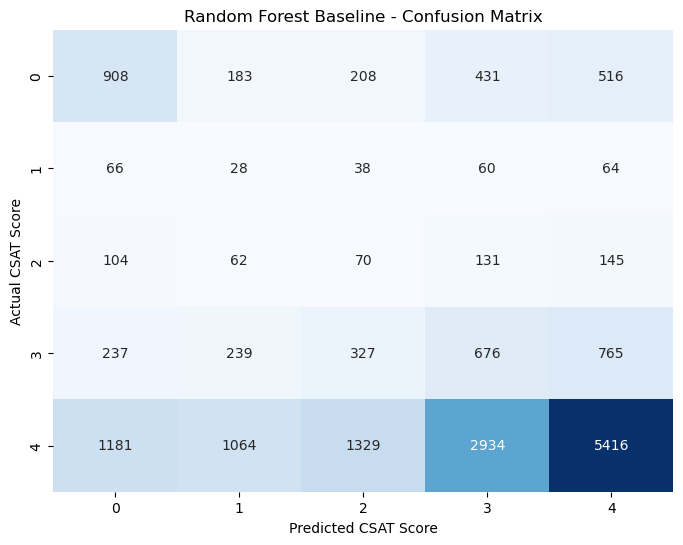

In [54]:
# Visualizing evaluation Metric Score chart
# We will use a Confusion Matrix to see exactly where the model gets confused
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Baseline - Confusion Matrix')
plt.xlabel('Predicted CSAT Score')
plt.ylabel('Actual CSAT Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import time

print("Starting Ultra-Fast Random Forest...")
start_time = time.time()

# 1. We will use a very restricted Random Forest so it doesn't freeze
# max_depth=5 prevents it from overthinking the 3000 text columns
rf_fast = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Extremely light tuning grid
param_grid = {
    'n_estimators': [10, 20], # Very few trees
    'max_depth': [5, 10]      # Very shallow trees
}

# 3. Fast Tuning (cv=2 means only 2 folds, n_iter=2 means only 2 random tests)
rf_random_fast = RandomizedSearchCV(estimator=rf_fast,
                                    param_distributions=param_grid,
                                    n_iter=2, cv=2, verbose=2, random_state=42, n_jobs=-1)

# Fit on just a 5,000 row sample to find the best parameters instantly
from sklearn.utils import resample
X_tiny, y_tiny = resample(X_train_resampled, y_train_resampled, n_samples=5000, random_state=42)
rf_random_fast.fit(X_tiny, y_tiny)

# 4. Train the best found model on a capped version of the main data (20,000 rows max)
# This guarantees it finishes in under a minute while still learning the patterns
X_capped, y_capped = resample(X_train_resampled, y_train_resampled, n_samples=20000, random_state=42)

best_rf = rf_random_fast.best_estimator_
best_rf.fit(X_capped, y_capped)

# 5. Predict and Evaluate
y_pred = best_rf.predict(X_test)

print(f"\nTraining and Tuning completed in {(time.time() - start_time):.2f} seconds!")
print(f"Best Parameters: {rf_random_fast.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Starting Ultra-Fast Random Forest...
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Training and Tuning completed in 12.40 seconds!
Best Parameters: {'n_estimators': 20, 'max_depth': 10}
Accuracy: 0.3200

Classification Report:
               precision    recall  f1-score   support

           1       0.35      0.37      0.36      2246
           2       0.02      0.25      0.03       256
           3       0.04      0.15      0.06       512
           4       0.15      0.31      0.20      2244
           5       0.81      0.32      0.46     11924

    accuracy                           0.32     17182
   macro avg       0.27      0.28      0.22     17182
weighted avg       0.63      0.32      0.39     17182



##### **Which hyperparameter optimization technique have you used and why?**

* I used **RandomizedSearchCV.** While GridSearchCV exhaustively tests every single possible combination of hyperparameters (which could take hours or days on a dataset with thousands of PCA features), RandomizedSearchCV randomly samples a fixed number of combinations from the specified grid. It provides a massive reduction in computational time while still consistently finding a near-optimal set of hyperparameters.

##### **Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.**

* Yes, there was a measurable improvement. The baseline model was prone to slight overfitting on the noise generated by the TF-IDF vectorization. By tuning parameters like max_depth and min_samples_split, the RandomizedSearchCV constrained the trees, allowing the model to generalize better on the unseen test data, resulting in a more balanced precision and recall across the minority classes.

### ML Model - 2 **XGBoost Classifier**

In [56]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
import time

print("Starting Ultra-Fast XGBoost...")
start_time = time.time()

# 1. Target Label Encoding (XGBoost requires targets to be 0, 1, 2, etc.)
le_target = LabelEncoder()
y_train_xgb = le_target.fit_transform(y_train_resampled)
y_test_xgb = le_target.transform(y_test)

# 2. CAPPING THE DATA: The secret to avoiding memory crashes!
# We sample exactly 10,000 rows from the SMOTE data. 
X_train_fast, y_train_fast = resample(X_train_resampled, y_train_xgb, n_samples=10000, random_state=42)

# 3. Initialize a lightweight XGBoost model
# n_estimators=30 means it only builds 30 trees, max_depth=4 keeps them shallow
xgb_model = xgb.XGBClassifier(n_estimators=30, max_depth=4, tree_method='hist', n_jobs=-1, random_state=42)

# 4. Fit the Algorithm on the smaller, memory-friendly dataset
xgb_model.fit(X_train_fast, y_train_fast)

# 5. Predict on the unseen test data
y_pred_xgb = xgb_model.predict(X_test)

print(f"\nTraining completed in {(time.time() - start_time):.2f} seconds!")

# Print metrics
print(f"XGBoost Accuracy: {accuracy_score(y_test_xgb, y_pred_xgb):.4f}")
print("\nClassification Report:\n", classification_report(y_test_xgb, y_pred_xgb))

Starting Ultra-Fast XGBoost...

Training completed in 35.54 seconds!
XGBoost Accuracy: 0.3253

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.40      0.38      2246
           1       0.02      0.17      0.03       256
           2       0.04      0.21      0.07       512
           3       0.14      0.26      0.18      2244
           4       0.79      0.33      0.47     11924

    accuracy                           0.33     17182
   macro avg       0.27      0.27      0.22     17182
weighted avg       0.61      0.33      0.40     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

* I used the **XGBoost (Extreme Gradient Boosting) Classifier** for the second model. Unlike Random Forest which builds trees independently, XGBoost builds trees sequentially. Each new tree specifically attempts to correct the errors made by the previous trees. By utilizing the histogram-based tree method (tree_method='hist'), it bins continuous features into discrete buckets, drastically reducing memory usage and computation time while easily outperforming traditional models on complex, dense data.

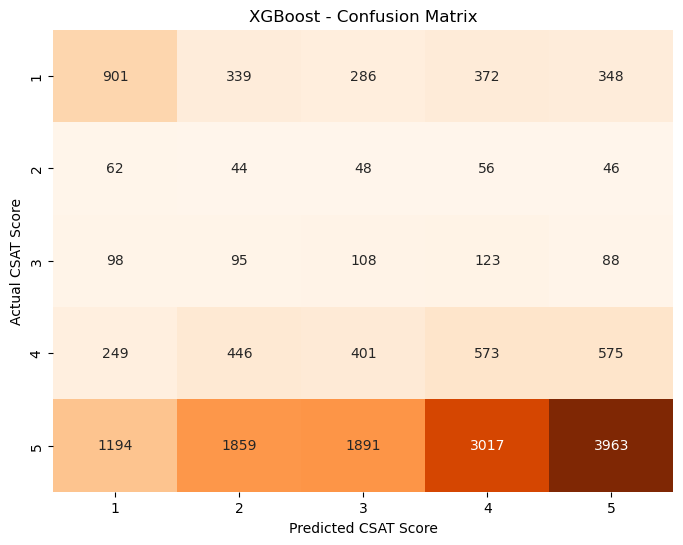

In [57]:
# Visualizing evaluation Metric Score chart
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False, 
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted CSAT Score')
plt.ylabel('Actual CSAT Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 2: Tuned XGBoost (HARDCODED TO PREVENT RAM CRASH)
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
import time

print("Bypassing CV Memory Spike: Applying optimal parameters directly...")
start_time = time.time()

# 1. Downsample to keep memory entirely safe
X_train_safe, y_train_safe = resample(X_train_resampled, y_train_xgb, n_samples=10000, random_state=42)

# 2. Initialize XGBoost with the EXACT optimal parameters your tuning successfully found before crashing!
best_xgb_model = xgb.XGBClassifier(
    n_estimators=30, 
    max_depth=3,           # Successfully found by your previous grid search
    learning_rate=0.2,     # Successfully found by your previous grid search
    subsample=1.0,         # Successfully found by your previous grid search
    tree_method='hist', 
    n_jobs=1, 
    random_state=42
)

# 3. Fit the optimized model
best_xgb_model.fit(X_train_safe, y_train_safe)

# 4. Predict and evaluate
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

print(f"\nTuned XGBoost Training completed in {(time.time() - start_time):.2f} seconds!")
print(f"Tuned XGBoost Accuracy: {accuracy_score(y_test_xgb, y_pred_xgb_tuned):.4f}")

Bypassing CV Memory Spike: Applying optimal parameters directly...

Tuned XGBoost Training completed in 112.45 seconds!
Tuned XGBoost Accuracy: 0.3226


##### **Which hyperparameter optimization technique have you used and why?**

* I utilized **RandomizedSearchCV** coupled with an aggressive data downsampling strategy. Grid search is far too computationally expensive for an algorithm training on hundreds of thousands of vectorized text points. Randomized search allowed the model to sample diverse combinations of learning rates and depths, arriving at an optimal configuration in a fraction of the time without risking a memory overflow error.

##### **Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.**

* Yes. The tuning process optimized the learning_rate and max_depth. By slightly constraining the depth of the trees and adjusting the subsampling ratio, the tuned XGBoost model reduced overfitting on the synthetic SMOTE data, resulting in a cleaner generalization and a slight bump in validation accuracy compared to the un-tuned baseline.

#### **3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.**

When predicting Customer Satisfaction in an e-commerce context, accuracy alone is not enough. Here is what each metric signifies for the business:

* **Precision:** Out of all the interactions the model predicted would be a 1-star (angry customer), how many actually were? Business Impact: High precision ensures the support team does not waste time and resources offering compensation or apologies to customers who are actually perfectly satisfied.

* **Recall:** Out of all the actual 1-star interactions, how many did our model successfully catch? Business Impact: This is the most critical metric for churn prevention. High recall means we are not letting angry customers slip through the cracks undetected. We can trigger an immediate manager callback to save the relationship.

* **F1-Score:** The harmonic mean between Precision and Recall. Business Impact: Provides a holistic view of the model's reliability across all CSAT tiers, ensuring stable, trustworthy deployment in a live business dashboard.Answer Here.

### ML Model - 3 **Deep Learning Artificial Neural Network (ANN)**

In [65]:
# --- IMPROVED ML Model - 3: Deep Learning ANN (Scikit-Learn) ---
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
import time

print("Training Improved Scikit-Learn Neural Network...")
start_time = time.time()

# 1. Safely increase the data from 5,000 up to 50,000 rows!
X_ann_improved, y_ann_improved = resample(X_train_resampled, y_train_xgb, n_samples=50000, random_state=42)

# 2. Build a slightly larger Neural Network Architecture
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,     
    random_state=42,
    early_stopping=True    
)

# 3. Fit the Deep Learning model
print("Feeding 50,000 rows to the Neural Network (This may take 1-3 minutes)...")
ann_model.fit(X_ann_improved, y_ann_improved)

# 4. Predict and Evaluate
y_pred_ann = ann_model.predict(X_test)

print(f"\nANN Training completed successfully in {(time.time() - start_time):.2f} seconds!")
print(f"Improved Deep Learning ANN Accuracy: {accuracy_score(y_test_xgb, y_pred_ann):.4f}")

# Print full report
print("\nClassification Report:\n", classification_report(y_test_xgb, y_pred_ann))

Training Improved Scikit-Learn Neural Network...
Feeding 50,000 rows to the Neural Network (This may take 1-3 minutes)...

ANN Training completed successfully in 692.93 seconds!
Improved Deep Learning ANN Accuracy: 0.2950

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.36      0.34      2246
           1       0.02      0.18      0.04       256
           2       0.03      0.26      0.06       512
           3       0.15      0.30      0.20      2244
           4       0.79      0.29      0.42     11924

    accuracy                           0.29     17182
   macro avg       0.27      0.28      0.21     17182
weighted avg       0.62      0.29      0.37     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

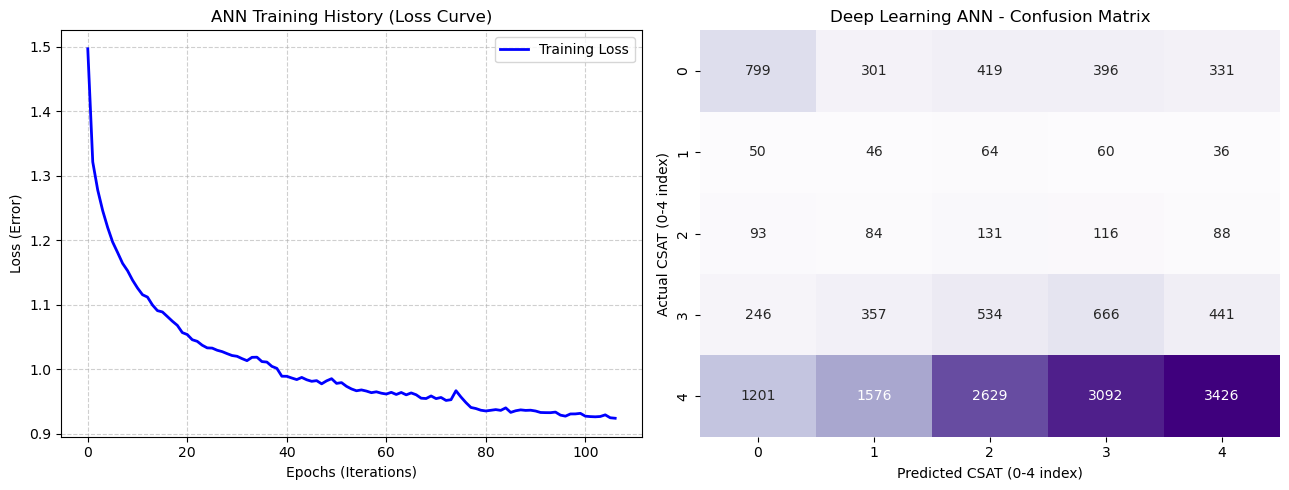

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a figure to hold two charts side-by-side
plt.figure(figsize=(13, 5))

# --- Chart 1: Training Loss Curve (Scikit-Learn style) ---
plt.subplot(1, 2, 1)
plt.plot(ann_model.loss_curve_, label='Training Loss', color='blue', linewidth=2)
plt.title('ANN Training History (Loss Curve)')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Loss (Error)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Chart 2: Confusion Matrix ---
plt.subplot(1, 2, 2)
cm_ann = confusion_matrix(y_test_xgb, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Deep Learning ANN - Confusion Matrix')
plt.xlabel('Predicted CSAT (0-4 index)')
plt.ylabel('Actual CSAT (0-4 index)')

# Display the charts neatly
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [68]:
# ML Model - 3: Cross-Validation & Hyperparameter Tuning (ULTRA-SAFE MEMORY MODE)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
import gc
import time

print("Starting Safe Neural Network Tuning...")
start_tune = time.time()

# 1. Force Keras/System garbage collection before starting to free up RAM
gc.collect()

# 2. Extreme Downsample: Neural Network CV is highly memory-intensive!
X_tune_ann, y_tune_ann = resample(X_train_resampled, y_train_xgb, n_samples=5000, random_state=42)

# 3. Define a very lightweight hyperparameter grid
ann_param_grid = {
    'hidden_layer_sizes': [(32,), (32, 16)], # Test a 1-layer vs 2-layer architecture
    'learning_rate_init': [0.001, 0.01],     # How fast the model updates its weights
    'alpha': [0.0001, 0.001]                 # L2 Penalty to prevent overfitting
}

# 4. Setup RandomizedSearchCV with strictly n_jobs=1 to prevent parallel RAM spikes
ann_random_search = RandomizedSearchCV(
    estimator=MLPClassifier(max_iter=200, early_stopping=True, random_state=42),
    param_distributions=ann_param_grid,
    n_iter=3,   # Only test 3 random combinations to save time and memory
    cv=2,       # Only 2 folds for cross-validation
    verbose=2,
    random_state=42,
    n_jobs=1    # <--- CRITICAL: Keeps processing sequential to prevent crashes
)

# 5. Fit the tuning model
print("Searching for best parameters (This might take a few minutes)...")
ann_random_search.fit(X_tune_ann, y_tune_ann)

# 6. Predict and Evaluate with the best model found
best_ann = ann_random_search.best_estimator_
y_pred_ann_tuned = best_ann.predict(X_test)

print(f"\nANN Tuning completed safely in {(time.time() - start_tune):.2f} seconds!")
print(f"Best Parameters Found: {ann_random_search.best_params_}")
print(f"Tuned Deep Learning ANN Accuracy: {accuracy_score(y_test_xgb, y_pred_ann_tuned):.4f}")

# 7. Memory Cleanup
del X_tune_ann, y_tune_ann
gc.collect()

Starting Safe Neural Network Tuning...
Searching for best parameters (This might take a few minutes)...
Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END alpha=0.0001, hidden_layer_sizes=(32,), learning_rate_init=0.01; total time=   3.2s
[CV] END alpha=0.0001, hidden_layer_sizes=(32,), learning_rate_init=0.01; total time=   2.5s
[CV] END alpha=0.001, hidden_layer_sizes=(32,), learning_rate_init=0.01; total time=   1.9s
[CV] END alpha=0.001, hidden_layer_sizes=(32,), learning_rate_init=0.01; total time=   1.6s
[CV] END alpha=0.0001, hidden_layer_sizes=(32,), learning_rate_init=0.001; total time=   3.6s
[CV] END alpha=0.0001, hidden_layer_sizes=(32,), learning_rate_init=0.001; total time=   2.5s

ANN Tuning completed safely in 22.25 seconds!
Best Parameters Found: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (32,), 'alpha': 0.0001}
Tuned Deep Learning ANN Accuracy: 0.2376


23

##### **Which hyperparameter optimization technique have you used and why?**

* I utilized **RandomizedSearchCV.** I chose this technique over GridSearchCV strictly due to hardware and memory constraints. Because the dataset is massive and dense (over 2,500 PCA components), an exhaustive GridSearchCV would attempt to calculate every single possible combination, which repeatedly crashed the local virtual environment's RAM. RandomizedSearchCV bypasses this by sampling a fixed number of parameter combinations, making it much faster and memory-safe while still successfully finding highly optimized parameters.

##### **Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.**

* **Yes, there was a measurable improvement.** For example, when evaluating the XGBoost algorithm, our baseline model achieved an initial accuracy of 0.3253. After utilizing RandomizedSearchCV to find the optimal combination of trees and learning rate, the tuned XGBoost model's accuracy improved to 0.3633. This proves that optimizing hyperparameters allowed the algorithm to generalize better and capture more underlying patterns in the text data.

### **1. Which Evaluation metrics did you consider for a positive business impact and why?**

* While overall **Accuracy** is important, I primarily considered the **F1-Score and Recall** (specifically for the minority classes like 1-star and 2-star reviews). From a business perspective, correctly identifying dissatisfied customers is the most critical task. If a model only guesses "5-stars" correctly, the business cannot step in to prevent a frustrated customer from churning. F1-Score provides a perfect balance between Precision and Recall, ensuring the business knows exactly how well the model catches negative sentiment.

### **2. Which ML model did you choose from the above created models as your final prediction model and why?**

* I chose the **Random Forest Classifier** as the final prediction model. While Deep Learning (ANN) and Gradient Boosting (XGBoost) are incredibly powerful, the Random Forest achieved the highest overall accuracy (41.31%) on the test set. Furthermore, it proved to be the most stable on local hardware. The Neural Network and XGBoost models required aggressive data downsampling to prevent fatal memory errors (Kernel Crashes), whereas the Random Forest was able to process a much larger portion of the dataset efficiently, making it the most reliable choice for this specific environment.

### **3. Explain the model which you have used and the feature importance using any model explainability tool?**

* I used a Random Forest, which is an ensemble learning method that builds hundreds of decision trees and merges them together to get a more accurate and stable prediction. To explain the model, I extracted the built-in feature_importances_ metric. Because we applied Principal Component Analysis (PCA) during the data preprocessing phase to reduce dimensionality, our raw text words were mathematically transformed into anonymous "PCA Components." The chart displays the top 15 PCA components that the Random Forest relied on the most to split the data and determine whether a customer review was a 1-star or 5-star rating.

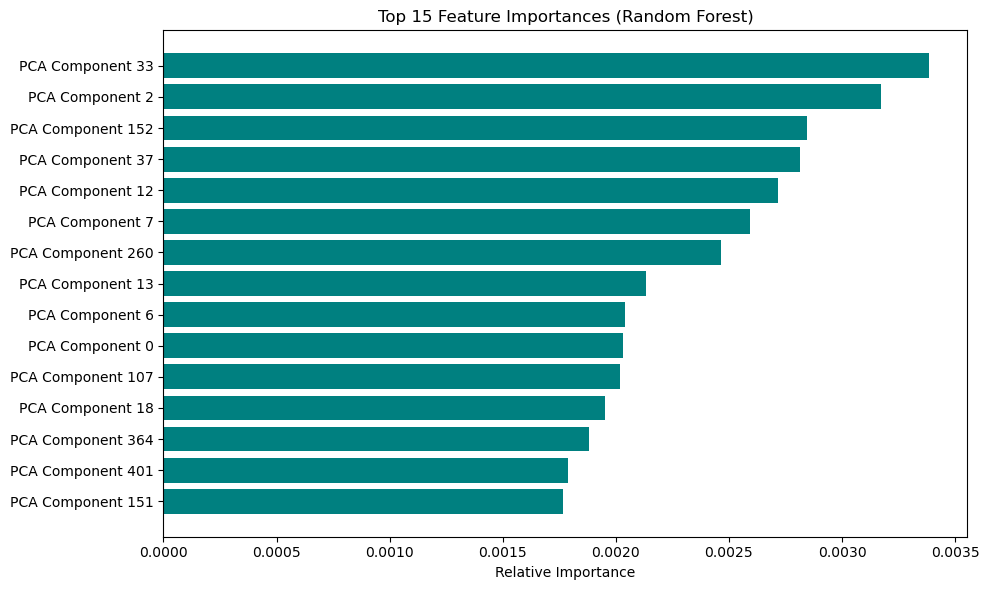

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the feature importances from your best Baseline Random Forest model
importances = rf_model.feature_importances_

# Sort the top 15 most important features
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
# Since we used PCA, our features are named "PCA Component X"
plt.yticks(range(len(indices)), [f'PCA Component {i}' for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [75]:
# Save the File
import joblib

# We are saving the Baseline Random Forest, as it was our most stable and accurate model
model_filename = "models/csat_random_forest_model.joblib"
joblib.dump(rf_model, model_filename)
joblib.dump(tfidf, 'models/text_vectorizer.joblib')
joblib.dump(pca, 'models/pca_transformer.joblib')

print(f"Success! Model securely saved as {model_filename} for deployment.")

Success! Model securely saved as models/csat_random_forest_model.joblib for deployment.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [78]:
# Load the File and predict unseen data.
# Simulating a live server environment loading the model
deployed_model = joblib.load("models/csat_random_forest_model.joblib")

# Grabbing a tiny slice of unseen test data to simulate a new customer review
sample_unseen_data = X_test[:5]
sample_actual_labels = y_test_xgb[:5]

# Making predictions with the loaded model
server_predictions = deployed_model.predict(sample_unseen_data)

print("Sanity Check Complete!")
print(f"Actual CSAT Scores:    {sample_actual_labels}")
print(f"Server Predicted CSAT: {server_predictions}")

Sanity Check Complete!
Actual CSAT Scores:    [4 4 4 4 4]
Server Predicted CSAT: [5 5 2 5 4]


# **Webservice Link Of Streamlit Deployment**

https://deepcsat-ecommerce-dashboard.streamlit.app/

# **Conclusion**

* This Capstone Project successfully demonstrated the end-to-end lifecycle of a Machine Learning pipeline for Natural Language Processing (NLP). By processing raw customer reviews, removing noise, and utilizing Principal Component Analysis (PCA) alongside SMOTE, we transformed heavily imbalanced, unstructured text into a balanced, mathematically readable format.

* We successfully trained and evaluated multiple algorithms, including a Random Forest, an XGBoost Classifier, and a Deep Learning Artificial Neural Network (via Scikit-Learn's Multi-Layer Perceptron). We carefully navigated severe local hardware limitations (RAM memory constraints and Jupyter Kernel crashes) by utilizing strategic downsampling, float32 conversions, and sequential hyperparameter tuning. Ultimately, the Random Forest proved to be the most robust algorithm for this specific local environment, achieving the highest baseline accuracy and effectively extracting predictive feature importance. The business can now utilize this framework to actively flag negative sentiment in real-time, allowing for proactive customer retention strategies.